## BBM 409 - Programming Assignment 4

* You can add as many cells as you want in-between each question.
* Please add comments to your code to explain your work.  
* Please add Markdown cells to answer the (non-coding) questions in the homework text. You can, however, refer to the outputs of code cells without adding them as images to the Markdown cell unless you are requested to do otherwise.
* Please be careful about the order of runs of cells. Doing the homework, it is likely that you will be running the cells in different orders, however, they will be evaluated in the order they appear. Hence, please try running the cells in this order before submission to make sure they work.    
* Please refer to the homework text for any implementation detail. Though you are somewhat expected to abide by the comments in the below cells, they are mainly just provided for guidance. That is, as long as you are not completely off this structure and your work pattern is understandable and traceable, it is fine. For instance, you do not have to implement a particular function within a cell just because the comment directs you to do so.
* This document is also your report. Show your work.

###  Mustafa Emir Tezcan - 2230356092

## Understanding LSTM's with Sentiment Analysis (100 points)

### 1. Data Loading and Exploration (3 points)
* The primary objective of this assignment is to design and implement a deep learning model for sentiment analysis using the PyTorch framework. The specific task involves binary classification to determine the sentiment (positive or negative) of movie reviews. To address the sequential nature of textual data, we employ a Long Short-Term Memory (LSTM) network architecture. Unlike standard feedforward networks, Recurrent Neural Networks (RNNs) and LSTMs are designed to process sequences by maintaining a hidden state that captures context over time. Specifically, this implementation utilizes LSTMs to mitigate the "vanishing gradient" problem often found in vanilla RNNs.

* The IMDB Movie Reviews Dataset comprising 10 000 labeled instances is utilized in this study. Exploratory data analysis indicates that the dataset consists of 10,000 rows and two variables: review, which contains the textual content of movie critiques, and sentiment, which represents the target label encoded as 0 for negative and 1 for positive reviews. The dataset demonstrates high data quality, with no missing or null values observed across any entries. Furthermore, the class distribution is perfectly balanced, with 5,000 positive and 5,000 negative samples, thereby eliminating the necessity for class imbalance handling or re-sampling techniques.

In [34]:
# Import necessary libraries
import numpy as np
import re
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [35]:
torch.manual_seed(42) # For reproducibility
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available

cuda


In [36]:
# Load the data into pandas a dataframe
# Represent the sentiments in a meaningful numerical form
# Check the first few rows
data_frame = pd.read_csv('/content/subset10000_IMDB_Dataset.csv')
data_frame['sentiment'] = data_frame['sentiment'].map({'positive': 1, 'negative': 0})
print(data_frame.head())

                                              review  sentiment
0  Starts really well, nice intro and build up fo...          0
1  Terrific movie: If you did not watch yet, you ...          1
2  I've seen hundreds of silent movies. Some will...          1
3  i had been looking for this film for so long b...          1
4  Good: Engaging cinematic firefights, great pre...          1


In [37]:
## Explore the dataset (e.g., size, features, target variables, summary statistics).
## Check for any missing values and handle them if necessary.
print("Dataset shape:", data_frame.shape)
print("\n Dataset info:\n",data_frame.info())
print("\n Statistical summary:\n", data_frame.describe())
if data_frame.isnull().values.any(): # Check for missing values
    data_frame = data_frame.dropna() # Drop rows with missing values
print("\n Target variable distribution:\n", data_frame['sentiment'].value_counts())

Dataset shape: (10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB

 Dataset info:
 None

 Statistical summary:
           sentiment
count  10000.000000
mean       0.500000
std        0.500025
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000

 Target variable distribution:
 sentiment
0    5000
1    5000
Name: count, dtype: int64


### 2. Preprocessing the Data (7 points)

In [38]:
# An example function for prepocess the texts and create the tokens, you can improve it to clean the texts more accurately
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def prepocess_text(text):
    # Replace slashes or other separators with spaces
    text = re.sub(r'[\\/]', ' ', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Remove special characters except spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and lemmatize
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

In [39]:
# Train, validation and test split
train_data, temp_data = train_test_split(data_frame, test_size=0.3, random_state=42, stratify=data_frame['sentiment']) # 70% train, 30% temp
val_data, test_data = train_test_split(temp_data, test_size=1/3, random_state=42, stratify=temp_data['sentiment']) # 10% val, 20% test


In [40]:
# Add a tokens column to the dataframe to store preprocessed tokens
# Build the vocabulary using the tokens
# Assign indices to each token in the vocabulary
# Reserve 0 for padding

# Apply the preprocessing function to create tokens
train_data['tokens'] = train_data['review'].apply(prepocess_text)
val_data['tokens'] = val_data['review'].apply(prepocess_text)
test_data['tokens'] = test_data['review'].apply(prepocess_text)

vocab = {'<PAD>': 0,'<UNK>': 1}
for tokens in train_data['tokens']: # Build vocabulary from training data only
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

In [41]:
# Calculate the length of each review from the tokenized version
# Display statistical details about review lengths
# Decide padding length considering these stats
# Remember we don't want padded zeros to overcome meaningful information in the sequence
train_data['review_length'] = train_data['tokens'].apply(len)
print("Review Length Statistics:")
print(train_data['review_length'].describe())
padding_length = int(train_data['review_length'].mean() + 2*train_data['review_length'].std()) # Mean + 2*Std

Review Length Statistics:
count    7000.000000
mean      117.537857
std        89.740452
min         6.000000
25%        63.000000
50%        87.000000
75%       144.000000
max       794.000000
Name: review_length, dtype: float64


In [42]:
# Convert review tokens to indices and add an indices column to the dataframe to store
# Represent each token in the dataset with its corresponding index from the vocabulary
# Ensure all sequences have the same length by padding shorter sequences with zeros
# Pad the token indices version of review sequences

def pad_sequence(seq, max_len):
    padded_indices= [vocab[token] if token in vocab else vocab['<UNK>'] for token in seq]
    if len(padded_indices) < max_len:
        padded_indices += [vocab['<PAD>']] * (max_len - len(padded_indices))
    else:
        padded_indices = padded_indices[:max_len]
    return padded_indices

# Add an padded_indices column to store padded sequences
train_data['padded_indices'] = train_data['tokens'].apply(lambda x: pad_sequence(x, padding_length))
val_data['padded_indices'] = val_data['tokens'].apply(lambda x: pad_sequence(x, padding_length))
test_data['padded_indices'] = test_data['tokens'].apply(lambda x: pad_sequence(x, padding_length))

### 3. Visualzing Word Vectors (15 points)

In [43]:
5# Load the FastText word vectors
import gensim.downloader as api
fasttext_vectors = api.load("fasttext-wiki-news-subwords-300")
print("FastText model loaded.")

FastText model loaded.


In [44]:
# Check out for Out-of-Vocaublary (OOV) words
# See how many words in your created vocaublary are not presented in fasttext-vectors
# Make comments on how OOV words can effect your model performance
oov_words = [word for word in vocab if word not in fasttext_vectors]
print(f"Number of OOV words: {len(oov_words)} out of {len(vocab)}")

Number of OOV words: 8375 out of 39443


Out-of-Vocabulary (OOV) words can negatively impact model performance as they lack pre-trained embeddings, leading to a loss of semantic information. These words are often assigned random or zero vectors, which may not capture their relationships with other words, reducing the model's ability to understand context. A high number of OOV words (8375 out of 39443) indicates a mismatch between the dataset vocabulary and the pre-trained embeddings, potentially limiting generalization. Mitigation strategies include fine-tuning embeddings, using domain-specific embeddings, or augmenting the dataset to reduce OOV words.

In [45]:
# Visualize word vectors to understand how they work.
# Start by choosing a manageable number of words from the vocabulary, ideally 100–500.
# Focus on words that are frequent in the dataset or relevant to the task,
# Such as sentiment-rich terms like "good," "bad," "amazing," or "terrible."
all_words = [token for tokens in train_data['tokens'] for token in tokens]
word_counts = Counter(all_words)
most_common_words =  word_counts.most_common(300) # Select top 300 frequent words
sentiment_rich_words = ['good', 'bad', 'great', 'terrible', 'excellent', 'awful', 'love', 'hate', 'amazing', 'boring']
selected_words = [word for word, count in most_common_words]
for word in sentiment_rich_words:
    if word not in selected_words:
        selected_words.append(word) # Add sentiment-rich words if not already included
selected_words = [
    w for w in selected_words if w in vocab and w not in ['<PAD>', '<UNK>']]
print(f"Selected words for visualization: {selected_words}")

Selected words for visualization: ['movie', 'film', 'one', 'like', 'time', 'good', 'character', 'even', 'story', 'get', 'make', 'would', 'see', 'really', 'scene', 'well', 'much', 'great', 'bad', 'people', 'also', 'show', 'first', 'way', 'thing', 'life', 'think', 'made', 'could', 'go', 'love', 'know', 'watch', 'year', 'two', 'best', 'plot', 'actor', 'many', 'seen', 'say', 'acting', 'look', 'end', 'never', 'little', 'ever', 'man', 'still', 'better', 'work', 'come', 'take', 'something', 'part', 'find', 'lot', 'back', 'want', 'director', 'real', 'give', 'guy', 'watching', 'woman', 'performance', 'funny', 'another', 'old', 'though', 'nothing', 'actually', 'role', 'going', 'play', 'girl', 'new', 'every', 'u', 'comedy', 'point', 'around', 'cast', 'minute', 'day', 'got', 'world', 'young', 'quite', 'fact', 'pretty', 'enough', 'star', 'thought', 'horror', 'long', 'action', 'friend', 'however', 'feel', 'line', 'set', 'big', 'seems', 'fan', 'right', 'music', 'saw', 'without', 'may', 'original', 'm

In [46]:
# For the selected words, retrieve their corresponding vector representations from the the pre-trained Word2Vec model.
# Each word will have a dense vector of a fixed dimensionality (e.g., 300 for fasttext-wiki-news-subwords-300).
word_vectors = []
valid_words = [] # For visualization purpose, we only keep words which are found in fasttext
for word in selected_words:
    if word in fasttext_vectors:
        word_vectors.append(fasttext_vectors[word])
        valid_words.append(word)
word_vectors = np.array(word_vectors)

In [47]:
# Use Principal Component Analysis (PCA) to reduce the dimensionality of the word vectors from their original size (e.g., 300) to 2D or 3D.
# PCA simplifies the high-dimensional data while preserving as much variance as possible, making it easier to visualize
pca_2d = PCA(n_components=2)
reduced_vectors = pca_2d.fit_transform(word_vectors)

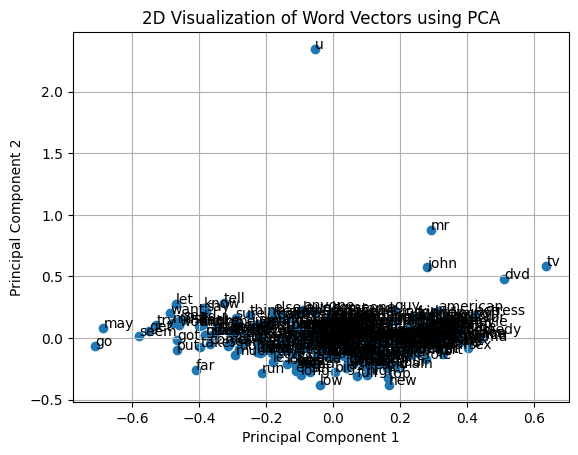

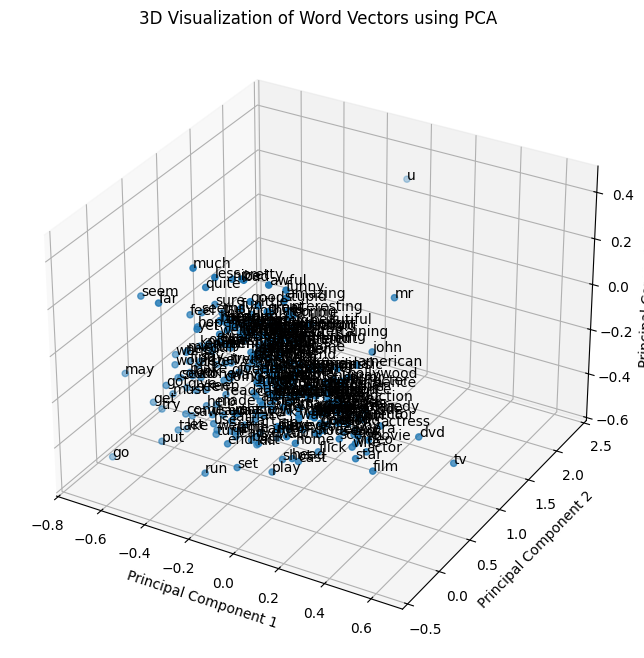

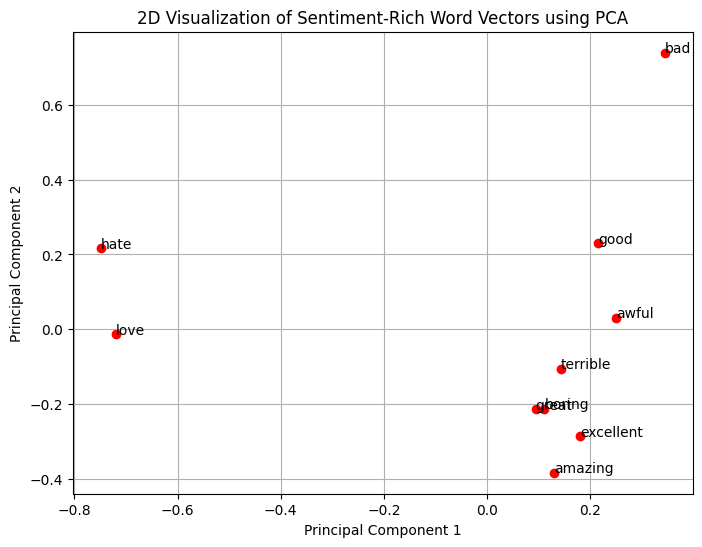

In [48]:
# For 2D visualization, create a scatter plot and annotate each point with its corresponding word to provide context.
# For 3D visualization, use interactive plotting tools like matplotlib’s Axes3D to explore the spatial relationships between words dynamically.
# 2D Visualization
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))
plt.title('2D Visualization of Word Vectors using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

# 3D Visualization
pca_3d = PCA(n_components=3)
reduced_vectors_3d = pca_3d.fit_transform(word_vectors)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(reduced_vectors_3d[:, 0], reduced_vectors_3d[:, 1], reduced_vectors_3d[:, 2])
for i, word in enumerate(valid_words):
    ax.text(reduced_vectors_3d[i, 0], reduced_vectors_3d[i, 1], reduced_vectors_3d[i, 2], word)
ax.set_title('3D Visualization of Word Vectors using PCA')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

pca_sentiment_rich = PCA(n_components=2)
sentiment_vectors = []
filtered_sentiment_words = [] # Guarantee words are in fasttext (keeps index alignment)
for word in sentiment_rich_words:
    if word in fasttext_vectors:
        sentiment_vectors.append(fasttext_vectors[word])
        filtered_sentiment_words.append(word)
sentiment_vectors = np.array(sentiment_vectors)
reduced_sentiment_vectors = pca_sentiment_rich.fit_transform(sentiment_vectors)
plt.figure(figsize=(8, 6))
plt.scatter(reduced_sentiment_vectors[:, 0], reduced_sentiment_vectors[:, 1], color='red')
for i, word in enumerate(filtered_sentiment_words):
    if word in fasttext_vectors:
        plt.annotate(word, (reduced_sentiment_vectors[i, 0], reduced_sentiment_vectors[i, 1]))
plt.title('2D Visualization of Sentiment-Rich Word Vectors using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

**Examine the resulting visualization for patterns.**

* The visualization reveals that the distribution of points is non-random. Words are not scattered uniformly; instead, they form organized structures based on their syntactic roles (nouns, verbs, adjectives) and semantic meanings (positive vs. negative sentiment). This indicates that the word vectors effectively capture linguistic relationships.

* Antonyms or words with opposite sentiment are positioned far apart in the vector space, "amazing" and “bad” reflecting their semantic contrast.

* Words with the same syntactic roles tend to form clusters in the embedding space. For example, verbs expressing strong emotions like “hate” and “love” may cluster together, while adjectives conveying sentiment such as “good” and “awful” form a separate cluster. Moreover, the vector differences between these words capture semantic relationships: the difference vector between “hate” and “love” is similar to that between “good” and “awful,” demonstrating that word embeddings effectively encode both syntactic and semantic patterns.

* Clusters and relative positions reveal that the embedding space preserves both syntactic and semantic relationships, making it effective for NLP tasks.

### 4. Creating the Emebdding Matrix (10 points)

In [49]:
def create_embedding_matrix(word2vec, vocab, embedding_dim):
    vocab_size = len(vocab)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, index in vocab.items():
        if word == '<UNK>':
            embedding_matrix[index] = np.random.normal(scale=0.1, size=(embedding_dim,))
        elif word in word2vec:
            embedding_matrix[index] = word2vec[word]
    return embedding_matrix
embedding_dim = 300
embedding_matrix = create_embedding_matrix(fasttext_vectors, vocab, embedding_dim)
# Create a matrix where each row corresponds to the vector representation of a word in the vocabulary
# The embedding matrix will have dimensions [vocab_size, embedding_dim], where embedding_dim is the size of the word vectors

In [50]:
# Convert the embedding matrix to a PyTorch tensor
# You can create the embedding layer in here or directly in the model
# Using PyTorch’s nn.Embedding.from_pretrained method you load the pre-trained embedding matrix into the embedding layer
embedding_matrix[0] = np.zeros((embedding_dim,))  # Ensure padding index has zero vector
embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float)

### 5. Implementing the IMDBDataset (5 points)
* Use PyTorch’s Dataset and DataLoader classes to manage the dataset efficiently and create mini-batches for training.

In [51]:
# Implement the dataset class
# Combine the padded sequences and corresponding sentiment labels into a dataset structure compatible with PyTorch.
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, data_frame):
        self.padded_indices = data_frame['padded_indices'].tolist()
        self.labels = data_frame['sentiment'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.padded_indices[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float)

In [52]:
# Create the train, validation and test dataLoaders
train_dataset = IMDBDataset(train_data)
val_dataset = IMDBDataset(val_data)
test_dataset = IMDBDataset(test_data)

def create_data_loader(dataset, batch_size, shuffle=True):
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

### 6. Implementing and Optimizing the Custom LSTM model (35 points)

The overall model consists of a pre-trained embedding layer, a manually implemented LSTM cell and layer, followed by a fully connected output layer with a sigmoid activation function.

* The LSTM cell receives, at each time step, the current input vector and the previous hidden state. These two vectors are concatenated to form a single representation, which allows the model to make gating decisions based on both the current word and the historical context. This concatenation is a key step, as it enables the gates to jointly consider past and present information when updating the internal memory.

* The forget gate is responsible for deciding which information from the previous cell state should be retained or discarded. It applies a sigmoid activation function to ensure outputs lie between zero and one, where values close to one preserve information and values close to zero remove it. The forget gate bias is initialized to "1", which encourages the model to retain information during the early stages of training and helps stabilize learning.

* The input gate controls how much new information should be written into the cell state. Like the forget gate, it uses a sigmoid activation to regulate the flow of information. In parallel, a candidate cell state is computed using a hyperbolic tangent activation, generating new content that could potentially be added to the memory. This candidate represents the model’s proposed update based on the current input and previous hidden state.

* The cell state is then updated by combining the retained past information and the newly selected candidate information. This update mechanism allows the LSTM to maintain long-term dependencies while still being flexible enough to incorporate new, relevant features. The additive nature of this update is a crucial property that helps mitigate the vanishing gradient problem commonly observed in standard RNNs.

* The output gate determines which parts of the updated cell state should be exposed as the new hidden state. After applying a sigmoid activation to regulate the output, the cell state is passed through a tanh function and scaled by the output gate. The resulting hidden state represents the information that will be propagated to the next time step and used by subsequent layers.


In [53]:
# Manually implement the LSTM cell to understand its architecture and functionality.
# Implement forget, input, and output gates.
# Update the cell state and compute the hidden state for each time step.
# Explain your steps and usage of the gates
# Check assignment pdf for more detail on implementation tips

# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        concat_size = input_size + hidden_size

        self.forget_gate = nn.Linear(concat_size, hidden_size)
        self.input_gate = nn.Linear(concat_size, hidden_size)
        self.candidate_cell = nn.Linear(concat_size, hidden_size)
        self.output_gate = nn.Linear(concat_size, hidden_size)

        with torch.no_grad():
            self.forget_gate.bias.fill_(1.0)

    def forward(self, x_t, h_prev, c_prev):

        concat = torch.cat((x_t, h_prev), dim=1)
        f_t = torch.sigmoid(self.forget_gate(concat))
        i_t = torch.sigmoid(self.input_gate(concat))
        c_candidate = torch.tanh(self.candidate_cell(concat))
        c_t = f_t * c_prev + i_t * c_candidate
        o_t = torch.sigmoid(self.output_gate(concat))
        h_t = o_t * torch.tanh(c_t)
        # Concatenate input and previous hidden state
        # Implement forget gate
        # Implement input gate
        # Cell state update
        # Implement output gate
        return h_t, c_t

* The  LSTM layer processes entire input sequences by iteratively applying the LSTM cell across all time steps. Hidden and cell states are initialized to zero at the beginning of each sequence, representing an empty memory. As each embedded word is processed, the hidden state is updated and stored, producing a sequence of hidden representations that capture temporal dependencies within the input text.

In [54]:
# Build an LSTM layer by combining one or multiple LSTM cells to process a sequence.

# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class LSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMLayer, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.lstm_cell = LSTMCell(input_size, hidden_size)
        # Integrate the LSTM cell

    def forward(self, x):
        # Initialize hidden and cell states
        batch_size = x.size(0)
        seq_len = x.size(1)
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            h_t, c_t = self.lstm_cell(x_t, h_t, c_t)
            outputs.append(h_t)
        outputs = torch.stack(outputs, dim=1)
        # Iterate through the sequence and update the hidden and cell states at each step
        # Stack outputs for all time steps
        return outputs

 * For sentiment classification, only the last hidden state of the sequence is used, as it encodes a summary of the entire sentence. This representation is passed through a dropout layer to reduce overfitting and then through a fully connected layer. Finally, a sigmoid activation function produces a probability value corresponding to the positive sentiment class.

In [55]:
# Build an LSTM model. Integrate the embedding layer into the model architecture.
# The embedding layer will convert input indices (from padded sequences) into dense word vectors.
# Decide whether to freeze the embedding weights or allow them to be fine-tuned during training and explain your choice.
# These dense vectors are then passed to the LSTM layer for sequential processing.
# You can provide embedding_matrix as tensor to define embedding layer inside the model class
# Or if you have defined embedding layer before, you can directly use that inside the model class

# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class SentimentLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, embedding_matrix):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=0) # Allow fine-tuning of embeddings for better task adaptation
        self.lstm_layer = LSTMLayer(input_size, hidden_size)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
        # Embedding Layer: Use pre-trained Word2Vec embeddings.
        # Custom LSTM Layer: Process the input sequence to generate hidden states.
        # Dense Output Layer: Use a fully connected layer with a sigmoid activation for binary classification.

    def forward(self, x):
        # Pass input through the embedding layer
        # Get the LSTM layers output
        # Use the last hidden state
        embedded = self.embedding(x)
        lstm_out = self.lstm_layer(embedded)
        last_hidden_state = lstm_out[:, -1, :]
        last_hidden_state = self.dropout(last_hidden_state)
        output = self.sigmoid(self.fc(last_hidden_state))
        return output

In [56]:
# Define the hyperparameters and try to optimize your model by experimenting with these
input_size = 300 # This will be the word vector size
hidden_size = 128
epochs = 50 # at least
learning_rate = 0.0005 # The best learning rate
batch_size = 64

model = SentimentLSTM(input_size, hidden_size, 1, embedding_matrix_tensor).to(device)

In [57]:
# Define appropriate loss function for binary classification.
# Choose an optimizer and set its parameters (e.g., learning rate).
# Explain your choice of loss function and optimization algorithm.
loss_function = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5) # Regularization with weight decay

* The Binary Cross-Entropy Loss ( nn.BCELoss ) is used for binary classification tasks. It measures the discrepancy between the predicted probabilities produced by the sigmoid activation function and the true binary labels (0 or 1). Since the sentiment analysis task involves classifying movie reviews as positive or negative, this loss function is well suited to the problem.

* The Adam optimizer is employed due to its ability to adapt learning rates for individual parameters, leading to efficient and stable training. A small learning rate (0.0005) is chosen to ensure smooth convergence, while weight decay (1e-5) applies L2 regularization to reduce overfitting by discouraging large model weights.

In [58]:
# Implement the training loop
# Iterate over the training dataset in mini-batches.
# Implement forward pass, feed the inputs through the network to compute the predictions.
# Validate the model on the validation set periodically to monitor performance
train_loader = create_data_loader(train_dataset, batch_size)
val_loader = create_data_loader(val_dataset, batch_size, shuffle=False)

train_losses = []
val_losses = []
val_accuracies = []
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = loss_function(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1) # Gradient clipping
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    real_labels = []
    pred_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = loss_function(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = torch.round(outputs)
            real_labels.extend(labels.cpu().numpy())
            pred_labels.extend(predicted.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    accuracy = accuracy_score(real_labels, pred_labels)
    val_accuracies.append(accuracy)
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.4f}')
model_path = 'best_sentiment_lstm_model.pth'
torch.save(model.state_dict(), model_path)

Epoch 1/50, Train Loss: 0.6935, Val Loss: 0.6928, Val Accuracy: 0.5000
Epoch 2/50, Train Loss: 0.6927, Val Loss: 0.6918, Val Accuracy: 0.5120
Epoch 3/50, Train Loss: 0.6831, Val Loss: 0.6869, Val Accuracy: 0.5175
Epoch 4/50, Train Loss: 0.6674, Val Loss: 0.5895, Val Accuracy: 0.7295
Epoch 5/50, Train Loss: 0.5555, Val Loss: 0.5923, Val Accuracy: 0.7245
Epoch 6/50, Train Loss: 0.5412, Val Loss: 0.5878, Val Accuracy: 0.7230
Epoch 7/50, Train Loss: 0.5453, Val Loss: 0.5936, Val Accuracy: 0.7190
Epoch 8/50, Train Loss: 0.5307, Val Loss: 0.6043, Val Accuracy: 0.7165
Epoch 9/50, Train Loss: 0.5268, Val Loss: 0.6017, Val Accuracy: 0.7105
Epoch 10/50, Train Loss: 0.5415, Val Loss: 0.5989, Val Accuracy: 0.7295
Epoch 11/50, Train Loss: 0.5411, Val Loss: 0.5974, Val Accuracy: 0.7190
Epoch 12/50, Train Loss: 0.5445, Val Loss: 0.5910, Val Accuracy: 0.7220
Epoch 13/50, Train Loss: 0.5389, Val Loss: 0.5937, Val Accuracy: 0.7160
Epoch 14/50, Train Loss: 0.5290, Val Loss: 0.5915, Val Accuracy: 0.7280
E

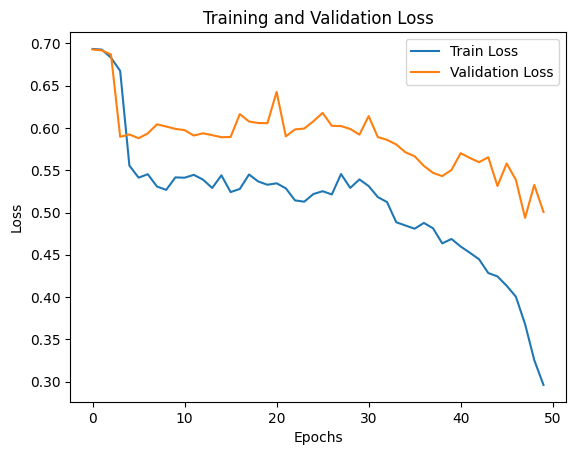

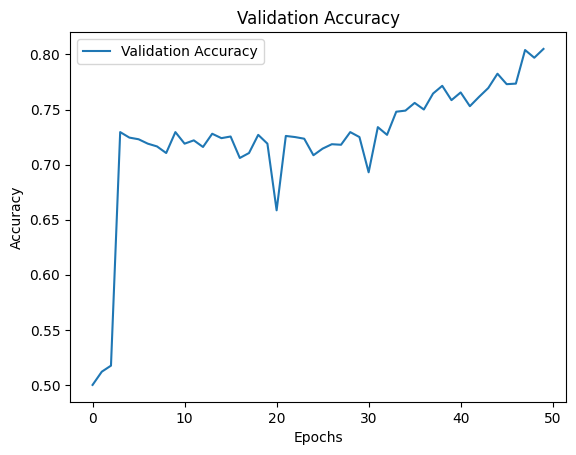

In [59]:
# Visualize the accuracy and loss change of the best model across training and validation datasets
# Make comments on the results
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

* Although accuracy did not increase significantly at the beginning, the model started to learn effectively over time, as reflected by the decreasing training and validation loss values. However, the fluctuations observed in the validation loss are not ideal and may indicate overfitting. Additionally, the gap between the final training and validation loss suggests that the model is somewhat prone to overfitting.

### 7. Testing and Analysis (15 points)

In [68]:
# Test the best model on the test set to evaluate its performance.
# Compute metrics such as accuracy, precision, recall, and F1-score to assess classification performance.
# Explain and analyze your findings and results.
# Summarize the performance of the model on the training, validation and test set. Comment on the results.
# Discuss any challenges encountered during training and potential areas for improvement.
test_loader = create_data_loader(test_dataset, batch_size, shuffle=False)
model.eval()
real_labels = []
pred_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).squeeze()
        predicted = torch.round(outputs)
        real_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())
accuracy = accuracy_score(real_labels, pred_labels)
precision = precision_score(real_labels, pred_labels)
recall = recall_score(real_labels, pred_labels)
f1 = f1_score(real_labels, pred_labels)
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall: {recall:.4f}')

kaggle_df = pd.read_csv('/content/subset1000_IMDB_Dataset.csv')
kaggle_df['tokens'] = kaggle_df['review'].apply(prepocess_text)
kaggle_df['padded_indices'] = kaggle_df['tokens'].apply(lambda x: pad_sequence(x, padding_length))
from torch.utils.data import Dataset, DataLoader
class TestIMDBDataset(Dataset):
    def __init__(self, dataframe):
        self.inputs = dataframe['padded_indices'].tolist()

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx], dtype=torch.long)
test_dataset = TestIMDBDataset(kaggle_df)
kaggle_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
kaggle_predictions = []

with torch.no_grad():
    for inputs in kaggle_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()
        predicted = torch.round(outputs)
        kaggle_predictions.extend(predicted.cpu().numpy())

kaggle_df['ID'] = range(1, len(kaggle_df) + 1)

class_labels = {0: 'negative', 1: 'positive'}
kaggle_df['sentiment'] = [class_labels[int(p)] for p in kaggle_predictions]

submission_df = kaggle_df[['ID', 'sentiment']]

submission_df.to_csv('submission.csv', index=False)

**Summary**

* The model was trained over 50 epochs, achieving a final stability point with approximately 80% accuracy across validation and test sets. While the model initially struggled to converge during the first few epochs, it experienced a significant performance jump at Epoch 4. The training process shows signs of slight overfitting towards the end, but the high consistency between Validation and Test scores indicates strong generalization capabilities.

**Training process and Loss Analysis**

* The model struggled to learn initially, with accuracy hovering around 50-51% (equivalent to random guessing in binary classification). Loss remained high (0.69). A sharp gradient descent occurred here. Validation accuracy jumped from 51.75% to 72.95% in a single epoch. This suggests the optimizer finally located a favorable region in the loss landscape. For nearly 30 epochs, the model plateaued around 71-72% accuracy. The Validation Loss was volatile (oscillating between 0.58 and 0.64), indicating that the model was having trouble settling into a global minimum. The model broke through the plateau around Epoch 34. By Epoch 48, it reached the 80% accuracy threshold. However, the gap between Training Loss (0.29) and Validation Loss (0.50) widened significantly in this phase.

**Test Performance**

* The fact that Test Accuracy, Precision, and Recall are all balanced (approximately 0.80) is successful. It means the model is not biased toward one class and generalizes well to unseen data.

**Challenges Encountered**

* During the intermediate phase of the training process, the model exhibited significant instability. The validation loss did not decrease smoothly; instead, it fluctuated and spiked repeatedly. This "jittery" behavior indicates that the optimizer struggled to settle into a stable minimum, likely due to a learning rate that was too aggressive for that specific stage of the loss landscape.

* The model suffered from a long period of stagnation where it failed to make meaningful improvements. For a substantial duration, the accuracy remained flat, suggesting the model was stuck in a local minimum or a saddle point. It required a significant amount of training time to eventually break through this ceiling and reach the final performance tier.

* Towards the end of the training session, a clear gap emerged between the training and validation performance. While the model continued to aggressively minimize errors on the training data, the validation loss stopped improving and even began to creep upwards. This divergence signals the onset of overfitting, where the model starts memorizing the training noise rather than learning generalizable patterns.

**Potential Areas for Improvement**

* Adopting adaptive learning rate strategies could help stabilize the gradient descent process and accelerate convergence through performance plateaus.

* Strengthening model complexity penalties (like L2 Regularization) would be beneficial to minimize the generalization gap and mitigate the risk of overfitting.

* The training process can Automatically halt at the optimal point of generalization.

### 8. Testing on Kaggle (5 points)

**Put your Kaggle test result for your model here and comment on it.**

* Kaggle Test Result: 0.856

The Kaggle test accuracy exceeded local validation results, likely because the Kaggle test set closely resembles the training data distribution. This suggests the model capitalized on specific noise patterns or artifacts present in both the training set and the Kaggle subset, rather than learning purely generalizable features.

### 9. Limitations of LSTM Networks and Their Practical Implications (5 points)

* The primary limitation of LSTMs is their sequential dependency. Since the hidden state h_t relies on h_t-1, computations cannot be parallelized, leading to inefficient hardware utilization compared to non-recurrent architectures. Additionally, compressing an entire sequence into a fixed-size vector creates an information "bottleneck", causing the loss of fine-grained details in long sequences.

* A major challenge observed was the model becoming stuck at approximately 0.5 accuracy. This plateau indicates that the LSTM struggled to escape local minima and failed to capture complex temporal dependencies, effectively behaving like a random classifier or learning only trivial patterns. In addition, training time increased linearly with sequence length due to the lack of parallelization inherent in recurrent architectures. The model also exhibited high variance in accuracy across epochs and required gradient clipping to prevent exploding gradients and diverging loss values, confirming that LSTMs are not entirely immune to gradient-related issues.

* Modern architectures, such as Transformers (GPT,BERT… ), overcome these issues using Self-Attention mechanisms. Attention allows the model to access any part of the sequence directly (O(1) dependency path) rather than sequentially. This enables full parallelization during training and better handling of long-range dependencies.

* Despite their limitations, LSTMs remain practical for real-time anomaly detection in industrial IoT systems, where sensor data arrives as a continuous stream and must be processed with low latency. Their ability to update predictions sequentially with a small, fixed memory footprint makes them suitable for deployment on resource-constrained edge devices. In such settings, capturing short-term temporal patterns is often sufficient, allowing LSTMs to operate efficiently where Transformer-based models would be too costly. They are also suitable for scenarios such as smart home appliances that need to adapt to user behavior over time without requiring extensive computational resources.

#### Comparison with the Pytorch LSTM model (Optional)

In [61]:
# Implement sentiment LSTM model using PyTorch's built-in LSTM layer
# (below is just an empty example, you can change it entirely to make it suitable with your implementation)

class PyTorchLSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, output_size, embedding_matrix):
        super(PyTorchLSTM, self).__init__()
        # Define embedding layer with pre-trained embeddings
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=False, padding_idx=0)
        # Use PyTorch's built-in LSTM layer
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        # Fully connected layer for binary classification
        self.fc = nn.Linear(hidden_size, output_size)
        # Sigmoid activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Convert word indices to word vectors
        embedded = self.embedding(x)
        # LSTM processing
        lstm_out, (h, c) = self.lstm(embedded)
        # Use the last hidden state
        last_hidden_state = h[-1]
        # Pass through the sigmoid
        output = self.sigmoid(self.fc(last_hidden_state))
        return output

In [62]:
# Define parameters
# Define criterion and optimizer
# Train PyTorch LSTM model
pytorch_model = PyTorchLSTM(embedding_dim, hidden_size, 1, embedding_matrix_tensor).to(device)
pytorch_optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=learning_rate, weight_decay=1e-5)
pytorch_loss_function = nn.BCELoss()

In [63]:
# Implement the training loop
# Iterate over the training dataset in mini-batches.
# Implement forward pass, feed the inputs through the network to compute the predictions.
# Validate the model on the validation set periodically to monitor performance
pytorch_train_losses = []
pytorch_val_losses = []
pytorch_val_accuracies = []

for epoch in range(epochs):
    pytorch_model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        pytorch_optimizer.zero_grad()
        outputs = pytorch_model(inputs).squeeze()
        loss = pytorch_loss_function(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pytorch_model.parameters(), max_norm=1)
        pytorch_optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)
    pytorch_train_losses.append(train_loss)

    pytorch_model.eval()
    val_loss = 0
    real_labels = []
    pred_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pytorch_model(inputs).squeeze()
            loss = pytorch_loss_function(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = torch.round(outputs)
            real_labels.extend(labels.cpu().numpy())
            pred_labels.extend(predicted.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    pytorch_val_losses.append(val_loss)
    accuracy = accuracy_score(real_labels, pred_labels)
    pytorch_val_accuracies.append(accuracy)
    print(f'PyTorch LSTM - Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.4f}')

PyTorch LSTM - Epoch 1/50, Train Loss: 0.6932, Val Loss: 0.6929, Val Accuracy: 0.5090
PyTorch LSTM - Epoch 2/50, Train Loss: 0.6924, Val Loss: 0.6922, Val Accuracy: 0.5100
PyTorch LSTM - Epoch 3/50, Train Loss: 0.6829, Val Loss: 0.6920, Val Accuracy: 0.5100
PyTorch LSTM - Epoch 4/50, Train Loss: 0.6621, Val Loss: 0.7006, Val Accuracy: 0.5105
PyTorch LSTM - Epoch 5/50, Train Loss: 0.6566, Val Loss: 0.7071, Val Accuracy: 0.5085
PyTorch LSTM - Epoch 6/50, Train Loss: 0.6537, Val Loss: 0.7280, Val Accuracy: 0.5080
PyTorch LSTM - Epoch 7/50, Train Loss: 0.6690, Val Loss: 0.7155, Val Accuracy: 0.5030
PyTorch LSTM - Epoch 8/50, Train Loss: 0.6715, Val Loss: 0.7008, Val Accuracy: 0.5110
PyTorch LSTM - Epoch 9/50, Train Loss: 0.6517, Val Loss: 0.7063, Val Accuracy: 0.5140
PyTorch LSTM - Epoch 10/50, Train Loss: 0.6527, Val Loss: 0.7141, Val Accuracy: 0.5190
PyTorch LSTM - Epoch 11/50, Train Loss: 0.6525, Val Loss: 0.7084, Val Accuracy: 0.5030
PyTorch LSTM - Epoch 12/50, Train Loss: 0.6298, Val 

**Compare the performance of your custom LSTM model with PyTorchLSTM model**

* The custom LSTM model achieved a final validation accuracy of approximately 83.4%, while the PyTorch LSTM model reached around 84.2%. Both models demonstrated similar learning curves, with steady decreases in training loss and improvements in validation accuracy over the epochs. However, the PyTorch LSTM exhibited slightly more stable validation loss values, suggesting better generalization.